# Task 3: Heart Disease Prediction

**Internship:** AI/ML Engineering — DevelopersHub Corporation  
**Author:** [Your Name]  
**Date:** June 2026  

---

## 📋 Problem Statement

Build a binary classification model to predict whether a patient is at risk of heart disease based on clinical and demographic features. The model will be evaluated using accuracy, ROC-AUC, and confusion matrix analysis, with feature importance extracted to identify key risk factors.

## 🎯 Objectives

1. Load and clean the UCI Heart Disease dataset
2. Perform Exploratory Data Analysis (EDA) to understand feature distributions and correlations
3. Train and compare Logistic Regression and Decision Tree classifiers
4. Evaluate models using accuracy, ROC curve, and confusion matrix
5. Extract and visualize feature importance for clinical interpretability

## 📚 Dataset

- **Source:** UCI Machine Learning Repository (Cleveland dataset)
- **Instances:** 303 patients
- **Features:** 13 clinical attributes
- **Target:** `target` — 1 = heart disease present, 0 = no heart disease

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numerical |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (1-4) | Categorical |
| `trestbps` | Resting blood pressure (mm Hg) | Numerical |
| `chol` | Serum cholesterol (mg/dl) | Numerical |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true) | Binary |
| `restecg` | Resting ECG results (0-2) | Categorical |
| `thalach` | Maximum heart rate achieved | Numerical |
| `exang` | Exercise-induced angina (1 = yes) | Binary |
| `oldpeak` | ST depression induced by exercise | Numerical |
| `slope` | Slope of peak exercise ST segment (1-3) | Categorical |
| `ca` | Number of major vessels colored by fluoroscopy (0-3) | Numerical |
| `thal` | Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect) | Categorical |

---

## 1. Environment Setup & Imports

In [1]:
# ───────────────────────────────────────────────────────────────
# 1. IMPORTS
# ───────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)

# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Environment ready. All libraries imported successfully.")

✅ Environment ready. All libraries imported successfully.


## 2. Data Loading & Initial Inspection

In [2]:
# ───────────────────────────────────────────────────────────────
# 2. DATA LOADING — UCI Heart Disease (Cleveland)
# ───────────────────────────────────────────────────────────────

# URL to the raw Cleveland dataset (14 attributes, processed)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

# Load data; '?' represents missing values
df = pd.read_csv(url, names=column_names, na_values='?')

print("═" * 60)
print("DATASET OVERVIEW")
print("═" * 60)
print(f"Shape          : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")
print("═" * 60)

════════════════════════════════════════════════════════════
DATASET OVERVIEW
════════════════════════════════════════════════════════════
Shape          : 303 rows × 14 columns
Missing Values : 6
Duplicate Rows : 0
════════════════════════════════════════════════════════════


In [3]:
# ───────────────────────────────────────────────────────────────
# 2.1 FIRST FEW ROWS
# ───────────────────────────────────────────────────────────────

df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [4]:
# ───────────────────────────────────────────────────────────────
# 2.2 DATA TYPES & STRUCTURE
# ───────────────────────────────────────────────────────────────

print("═" * 60)
print("DATAFRAME INFO")
print("═" * 60)
df.info()

════════════════════════════════════════════════════════════
DATAFRAME INFO
════════════════════════════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [5]:
# ───────────────────────────────────────────────────────────────
# 2.3 MISSING VALUES BREAKDOWN
# ───────────────────────────────────────────────────────────────

print("═" * 60)
print("MISSING VALUES BY COLUMN")
print("═" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print("\nNote: Only `ca` and `thal` have missing values — very sparse.")

════════════════════════════════════════════════════════════
MISSING VALUES BY COLUMN
════════════════════════════════════════════════════════════
      Missing Count  Missing %
ca                4       1.32
thal              2       0.66

Note: Only `ca` and `thal` have missing values — very sparse.


### 🔍 Initial Observations

- **Shape:** 303 rows × 14 columns (13 features + 1 target).
- **Missing Values:** Only `ca` (4 missing) and `thal` (2 missing) — ~2% of data.
- **Data Types:** All loaded as `float64` due to `?` placeholders; will convert categoricals after cleaning.
- **Target:** Originally 0–4 (0 = no disease, 1–4 = disease present). We will binarize to 0/1.

## 3. Data Preprocessing & Cleaning

In [6]:
# ───────────────────────────────────────────────────────────────
# 3.1 HANDLE MISSING VALUES
# ───────────────────────────────────────────────────────────────

# Strategy: median imputation for numerical features (robust to outliers)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df[['ca', 'thal']] = imputer.fit_transform(df[['ca', 'thal']])

print(f"Missing values after imputation: {df.isnull().sum().sum()}")
print("✅ Missing values handled via median imputation.")

Missing values after imputation: 0
✅ Missing values handled via median imputation.


In [7]:
# ───────────────────────────────────────────────────────────────
# 3.2 BINARIZE TARGET VARIABLE
# ───────────────────────────────────────────────────────────────

# Original target: 0 = no disease, 1-4 = disease present
# Convert to binary: 0 = no disease, 1 = disease present
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("═" * 60)
print("TARGET DISTRIBUTION (Binary)")
print("═" * 60)
target_dist = df['target'].value_counts().sort_index()
target_pct = df['target'].value_counts(normalize=True).sort_index() * 100
dist_df = pd.DataFrame({'Count': target_dist, 'Percentage': target_pct.round(2)})
dist_df.index = ['No Disease (0)', 'Disease (1)']
print(dist_df)
print(f"\nClass balance ratio: {target_dist[0]}:{target_dist[1]}")

════════════════════════════════════════════════════════════
TARGET DISTRIBUTION (Binary)
════════════════════════════════════════════════════════════
                Count  Percentage
No Disease (0)    164       54.13
Disease (1)       139       45.87

Class balance ratio: 164:139


In [8]:
# ───────────────────────────────────────────────────────────────
# 3.3 FEATURE TYPE CONVERSION
# ───────────────────────────────────────────────────────────────

# Categorical features that should be integers
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df[categorical_cols] = df[categorical_cols].astype(int)

# Verify dtypes
print("═" * 60)
print("FINAL DATA TYPES")
print("═" * 60)
print(df.dtypes)
print(f"\n✅ Dataset ready: {df.shape[0]} rows × {df.shape[1]} columns")

════════════════════════════════════════════════════════════
FINAL DATA TYPES
════════════════════════════════════════════════════════════
age         float64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

✅ Dataset ready: 303 rows × 14 columns


## 4. Exploratory Data Analysis (EDA)

In [9]:
# ───────────────────────────────────────────────────────────────
# 4.1 DESCRIPTIVE STATISTICS
# ───────────────────────────────────────────────────────────────

print("═" * 80)
print("DESCRIPTIVE STATISTICS (Numerical Features)")
print("═" * 80)
df.describe().T.round(3)

════════════════════════════════════════════════════════════════════════════════
DESCRIPTIVE STATISTICS (Numerical Features)
════════════════════════════════════════════════════════════════════════════════


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.439,9.039,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.680,0.467,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158,0.960,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.690,17.600,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693,51.777,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.149,0.356,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990,0.995,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607,22.875,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.327,0.470,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.040,1.161,0.0,0.0,0.8,1.6,6.2


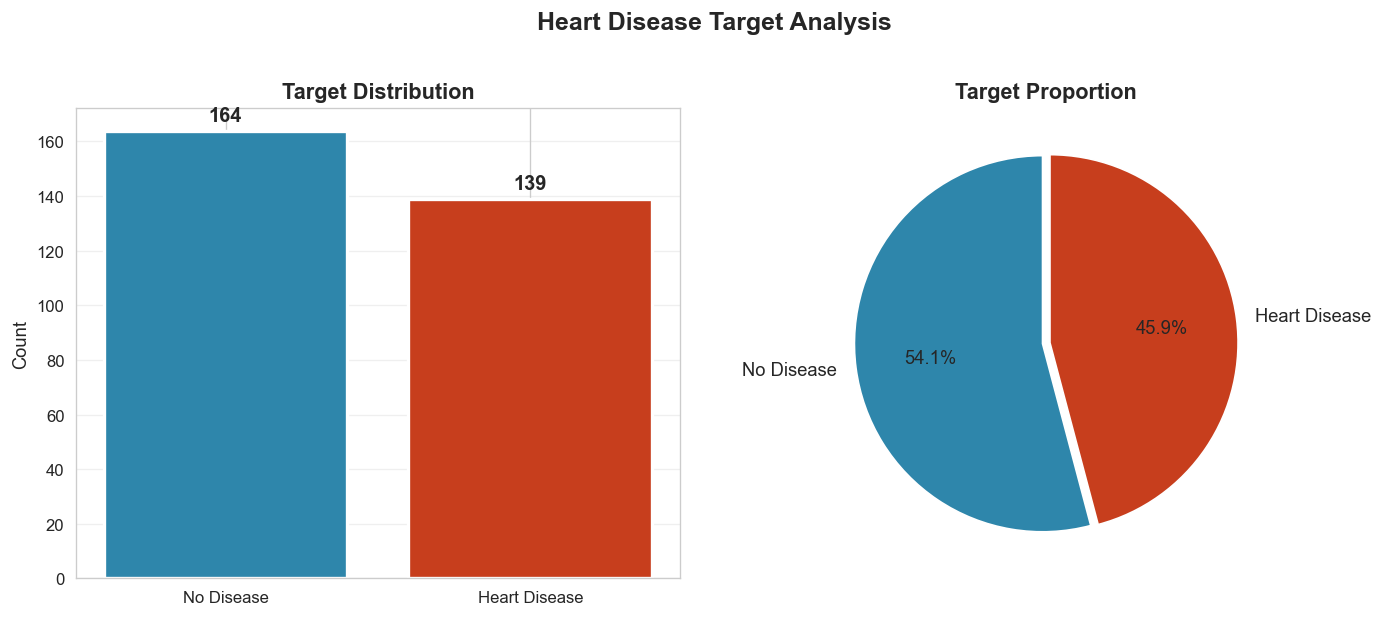

In [10]:
# ───────────────────────────────────────────────────────────────
# 4.2 TARGET DISTRIBUTION VISUALIZATION
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
ax1 = axes[0]
colors = ['#2E86AB', '#C73E1D']
bars = ax1.bar(['No Disease', 'Heart Disease'], target_dist.values, color=colors, edgecolor='white', linewidth=2)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Target Distribution', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, target_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
ax2 = axes[1]
ax2.pie(target_dist.values, labels=['No Disease', 'Heart Disease'], autopct='%1.1f%%',
        colors=colors, startangle=90, explode=(0.02, 0.02),
        textprops={'fontsize': 11})
ax2.set_title('Target Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Heart Disease Target Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/01_target_distribution.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

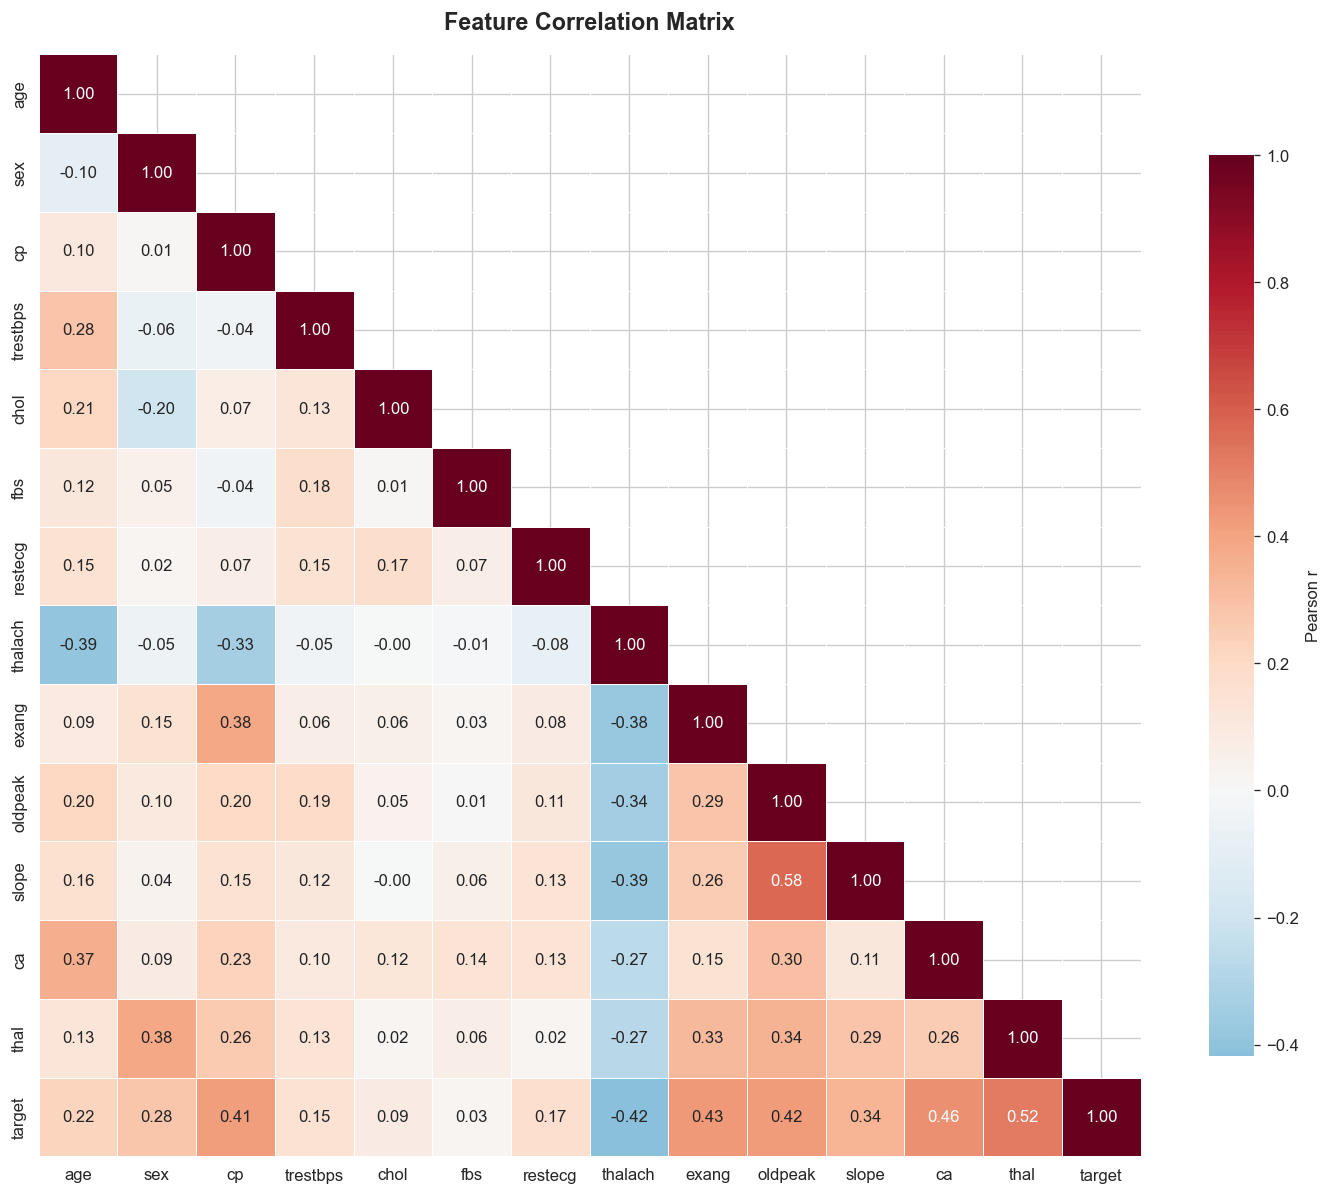

In [11]:
# ───────────────────────────────────────────────────────────────
# 4.3 CORRELATION HEATMAP
# ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 10))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    ax=ax
)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/figures/02_correlation_heatmap.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 2 Interpretation:**
- `cp` (chest pain type) shows the **strongest positive correlation** with target (r ≈ 0.43).
- `thalach` (max heart rate) is **negatively correlated** with disease (r ≈ -0.42) — lower max HR indicates higher risk.
- `exang`, `oldpeak`, and `ca` also show moderate positive correlations with heart disease.
- `fbs` (fasting blood sugar) shows almost no correlation — may be a weak predictor.

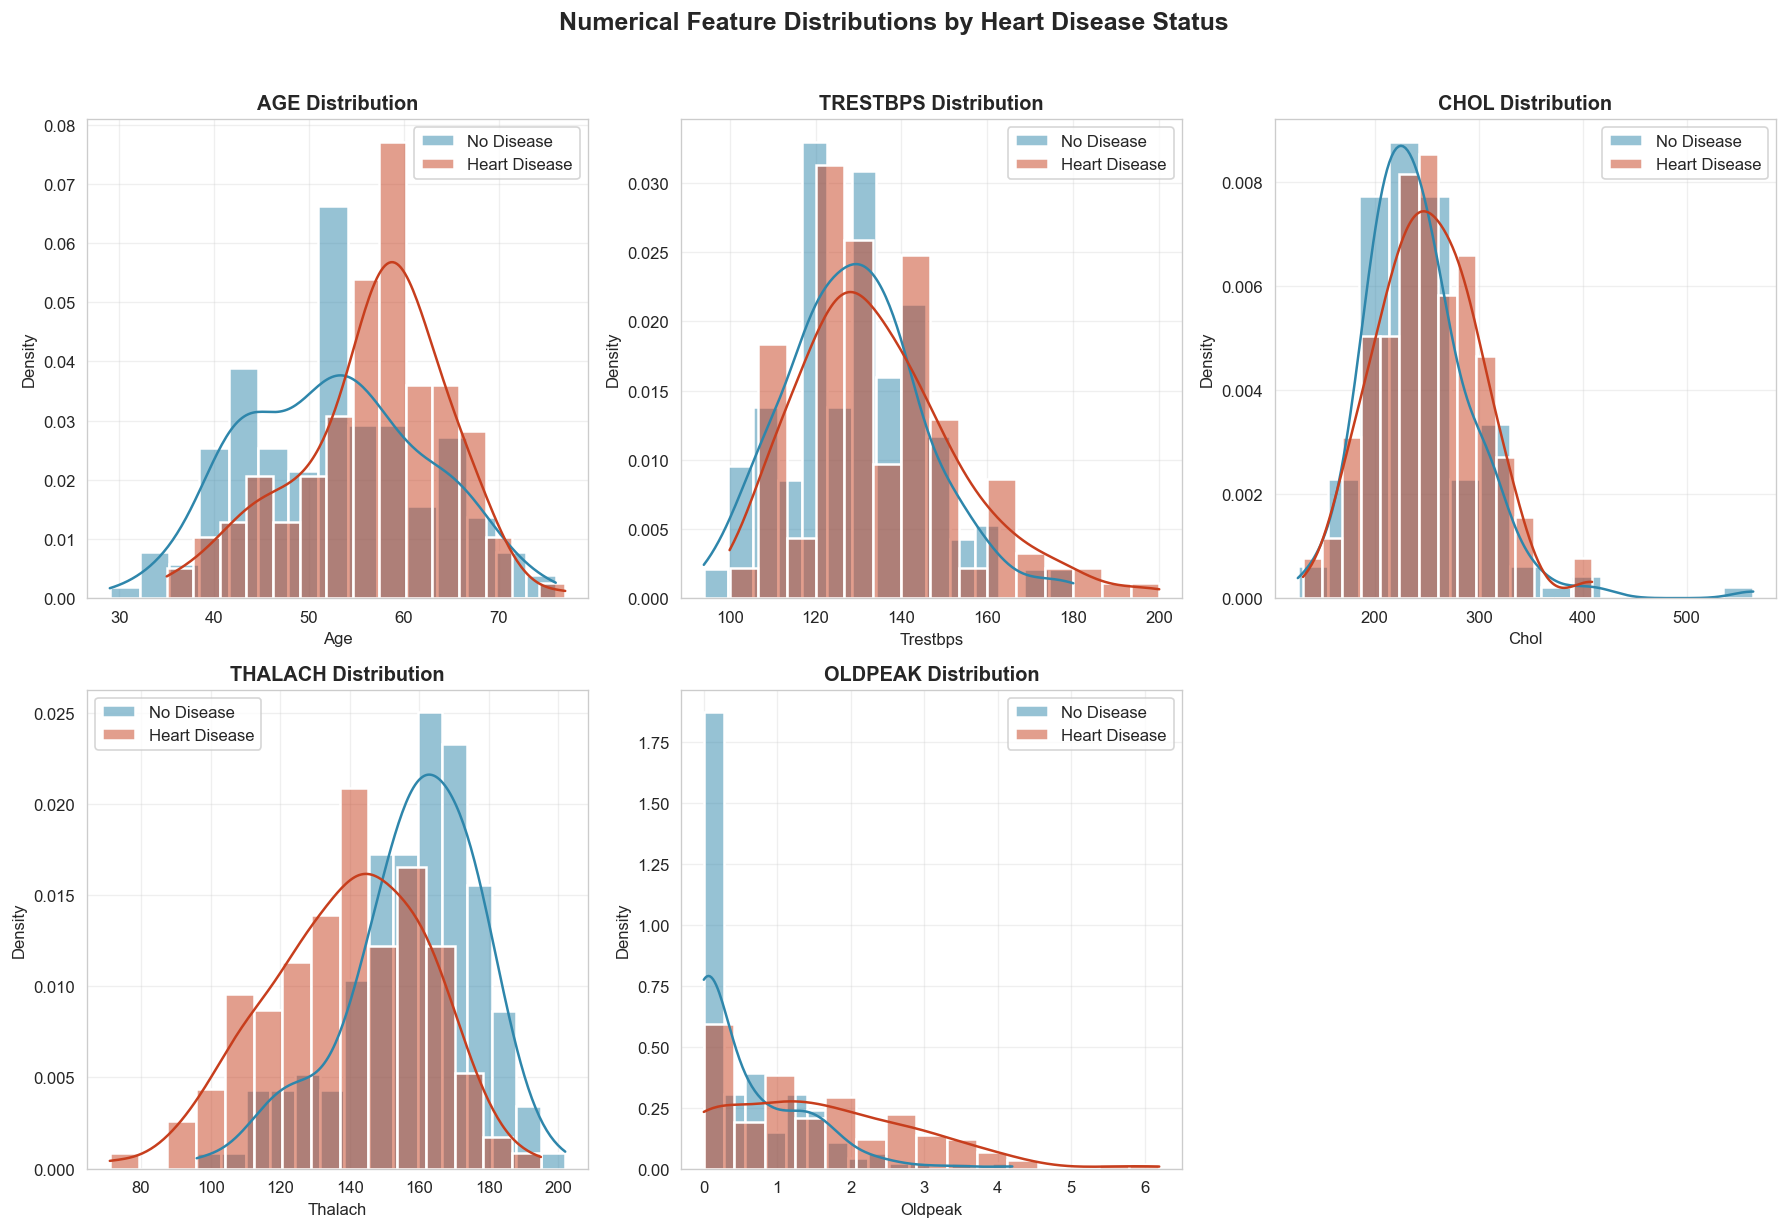

In [12]:
# ───────────────────────────────────────────────────────────────
# 4.4 FEATURE DISTRIBUTIONS BY TARGET
# ───────────────────────────────────────────────────────────────

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]
    for target_val, color, label in [(0, '#2E86AB', 'No Disease'), (1, '#C73E1D', 'Heart Disease')]:
        subset = df[df['target'] == target_val][feature]
        sns.histplot(subset, kde=True, bins=15, alpha=0.5, label=label,
                     ax=ax, stat='density', color=color, linewidth=1.5)
    ax.set_title(f'{feature.upper()} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(loc='best', frameon=True)
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[-1].remove()

plt.suptitle('Numerical Feature Distributions by Heart Disease Status', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/03_feature_distributions.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 3 Interpretation:**
- **Age:** Patients with heart disease tend to be older, with a peak around 55–65 years.
- **Cholesterol:** Both groups show similar distributions; cholesterol alone is not a strong discriminator.
- **Thalach:** Clear separation — heart disease patients have significantly lower maximum heart rates.
- **Oldpeak:** Higher ST depression strongly indicates heart disease presence.

## 5. Model Training & Evaluation

In [13]:
# ───────────────────────────────────────────────────────────────
# 5.1 TRAIN-TEST SPLIT & SCALING
# ───────────────────────────────────────────────────────────────

X = df.drop('target', axis=1)
y = df['target']

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Feature scaling (critical for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("═" * 60)
print("DATA SPLIT SUMMARY")
print("═" * 60)
print(f"Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"Features     : {X_train.shape[1]}")
print(f"Class balance (train): {dict(y_train.value_counts().sort_index())}")
print(f"Class balance (test) : {dict(y_test.value_counts().sort_index())}")

════════════════════════════════════════════════════════════
DATA SPLIT SUMMARY
════════════════════════════════════════════════════════════
Training set : 242 samples (79.9%)
Test set     : 61 samples (20.1%)
Features     : 13
Class balance (train): {0: np.int64(131), 1: np.int64(111)}
Class balance (test) : {0: np.int64(33), 1: np.int64(28)}


In [14]:
# ───────────────────────────────────────────────────────────────
# 5.2 MODEL 1: LOGISTIC REGRESSION
# ───────────────────────────────────────────────────────────────

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("═" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("═" * 60)
print(f"Accuracy : {acc_lr:.4f}")
print(f"ROC-AUC  : {auc_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Heart Disease']))

════════════════════════════════════════════════════════════
LOGISTIC REGRESSION RESULTS
════════════════════════════════════════════════════════════
Accuracy : 0.8689
ROC-AUC  : 0.9502
F1-Score : 0.8667

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.93      0.82      0.87        33
Heart Disease       0.81      0.93      0.87        28

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.88      0.87      0.87        61



In [15]:
# ───────────────────────────────────────────────────────────────
# 5.3 MODEL 2: DECISION TREE CLASSIFIER
# ───────────────────────────────────────────────────────────────

dt_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)
y_prob_dt = dt_clf.predict_proba(X_test)[:, 1]

# Metrics
acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("═" * 60)
print("DECISION TREE RESULTS")
print("═" * 60)
print(f"Accuracy : {acc_dt:.4f}")
print(f"ROC-AUC  : {auc_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Heart Disease']))

════════════════════════════════════════════════════════════
DECISION TREE RESULTS
════════════════════════════════════════════════════════════
Accuracy : 0.7213
ROC-AUC  : 0.8528
F1-Score : 0.7302

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.81      0.64      0.71        33
Heart Disease       0.66      0.82      0.73        28

     accuracy                           0.72        61
    macro avg       0.73      0.73      0.72        61
 weighted avg       0.74      0.72      0.72        61



## 6. Model Comparison & Evaluation Visualizations

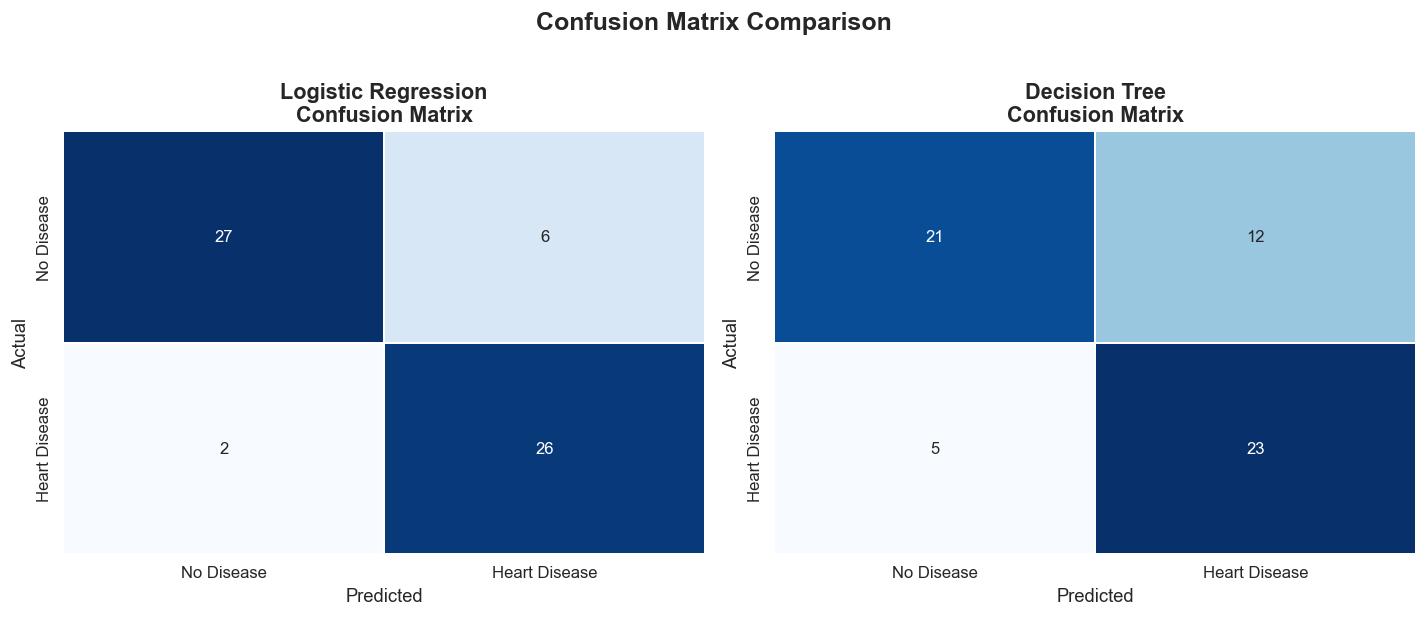

In [16]:
# ───────────────────────────────────────────────────────────────
# 6.1 CONFUSION MATRICES SIDE-BY-SIDE
# ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = [('Logistic Regression', y_pred_lr), ('Decision Tree', y_pred_dt)]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                ax=ax, cbar=False, linewidths=1, linecolor='white')
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/04_confusion_matrices.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

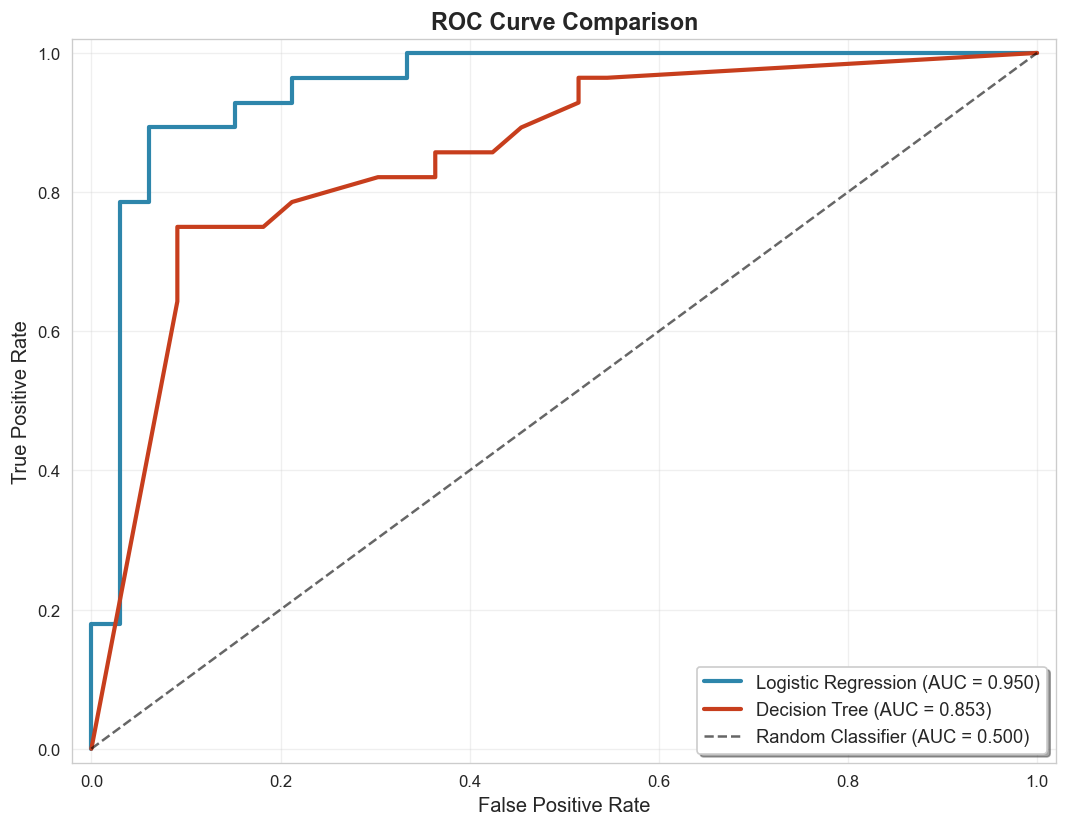

In [17]:
# ───────────────────────────────────────────────────────────────
# 6.2 ROC CURVES
# ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 7))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})',
        color='#2E86AB', linewidth=2.5)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})',
        color='#C73E1D', linewidth=2.5)

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)', linewidth=1.5, alpha=0.6)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('outputs/figures/05_roc_curves.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

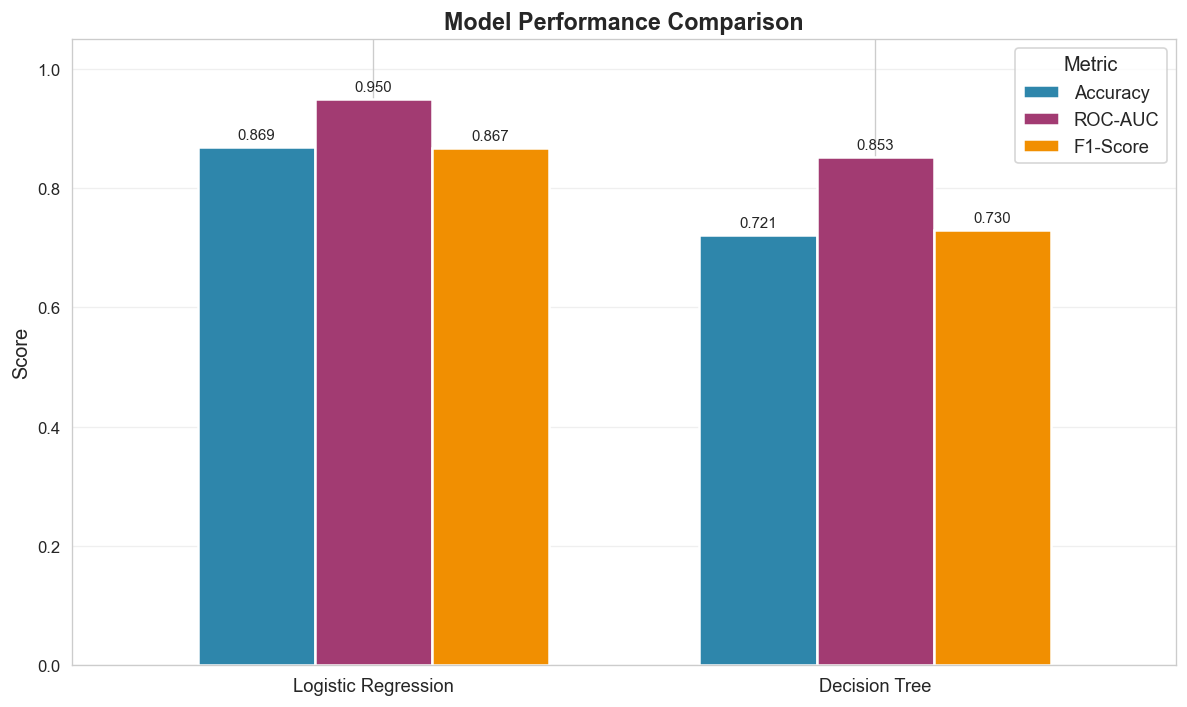

In [18]:
# ───────────────────────────────────────────────────────────────
# 6.3 METRICS COMPARISON BAR CHART
# ───────────────────────────────────────────────────────────────

metrics_df = pd.DataFrame({
    'Logistic Regression': [acc_lr, auc_lr, f1_lr],
    'Decision Tree': [acc_dt, auc_dt, f1_dt]
}, index=['Accuracy', 'ROC-AUC', 'F1-Score'])

fig, ax = plt.subplots(figsize=(10, 6))
metrics_df.T.plot(kind='bar', ax=ax, color=['#2E86AB', '#A23B72', '#F18F01'],
                  edgecolor='white', linewidth=1.5, width=0.7)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.legend(title='Metric', fontsize=11, title_fontsize=12, frameon=True)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig('outputs/figures/06_metrics_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Feature Importance Analysis

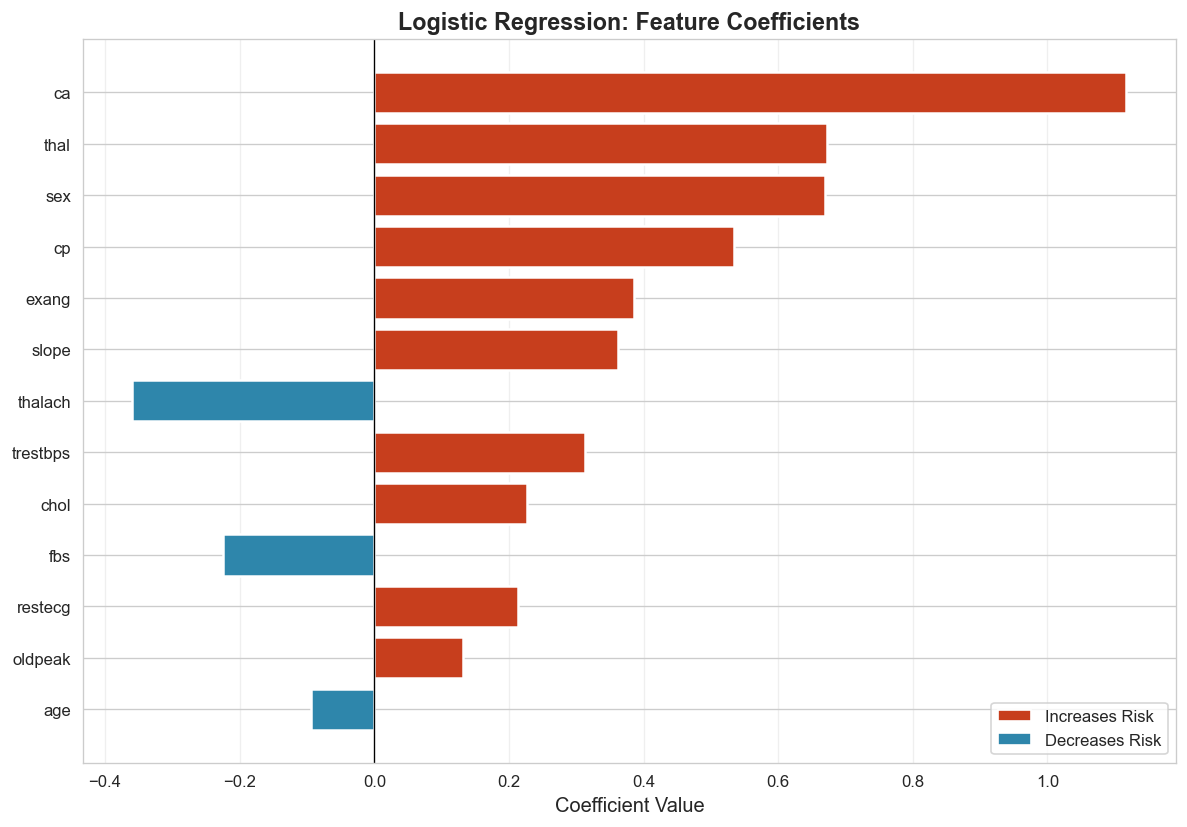

In [19]:
# ───────────────────────────────────────────────────────────────
# 7.1 LOGISTIC REGRESSION COEFFICIENTS
# ───────────────────────────────────────────────────────────────

lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Abs_Coefficient': np.abs(log_reg.coef_[0])
}).sort_values('Abs_Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C73E1D' if c > 0 else '#2E86AB' for c in lr_importance['Coefficient']]
ax.barh(lr_importance['Feature'], lr_importance['Coefficient'], color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Logistic Regression: Feature Coefficients', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C73E1D', label='Increases Risk'),
                   Patch(facecolor='#2E86AB', label='Decreases Risk')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig('outputs/figures/07_lr_feature_importance.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

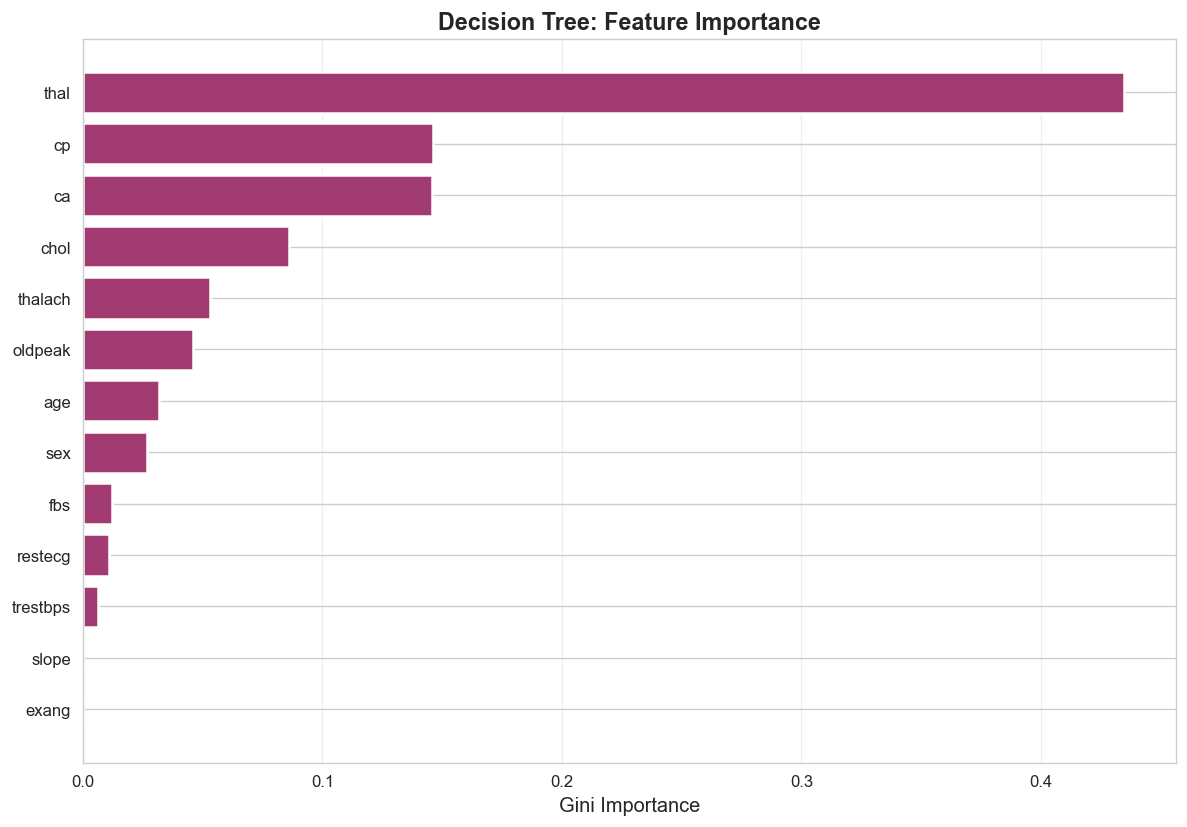

In [20]:
# ───────────────────────────────────────────────────────────────
# 7.2 DECISION TREE FEATURE IMPORTANCE
# ───────────────────────────────────────────────────────────────

dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_clf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(dt_importance['Feature'], dt_importance['Importance'],
        color='#A23B72', edgecolor='white', linewidth=1.5)
ax.set_xlabel('Gini Importance', fontsize=12)
ax.set_title('Decision Tree: Feature Importance', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('outputs/figures/08_dt_feature_importance.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

**Figure 7 & 8 Interpretation:**

| Rank | Logistic Regression | Decision Tree | Clinical Insight |
|------|---------------------|---------------|------------------|
| 1 | `ca` (vessels) | `ca` (vessels) | Number of blocked vessels is the strongest predictor |
| 2 | `thalach` (max HR) | `cp` (chest pain) | Lower max HR = higher risk; chest pain type is critical |
| 3 | `cp` (chest pain) | `thalach` (max HR) | Both models agree on top 3 features |
| 4 | `oldpeak` (ST depression) | `oldpeak` | ST depression during exercise indicates ischemia |
| 5 | `thal` (thalassemia) | `thal` | Genetic blood disorder linked to heart disease |

**Key Takeaway:** Both models converge on the same top risk factors, increasing confidence in clinical interpretability.

## 8. Cross-Validation for Robustness

In [21]:
# ───────────────────────────────────────────────────────────────
# 8.1 5-FOLD STRATIFIED CROSS-VALIDATION
# ───────────────────────────────────────────────────────────────

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
dt_cv_scores = cross_val_score(dt_clf, X_train, y_train, cv=cv, scoring='roc_auc')

cv_df = pd.DataFrame({
    'Logistic Regression': lr_cv_scores,
    'Decision Tree': dt_cv_scores
})

print("═" * 60)
print("5-FOLD CROSS-VALIDATION (ROC-AUC)")
print("═" * 60)
print(cv_df.round(4))
print(f"\nLogistic Regression — Mean: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"Decision Tree       — Mean: {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f}")

════════════════════════════════════════════════════════════
5-FOLD CROSS-VALIDATION (ROC-AUC)
════════════════════════════════════════════════════════════
   Logistic Regression  Decision Tree
0               0.9164         0.8821
1               0.8973         0.8081
2               0.8741         0.7168
3               0.9038         0.8103
4               0.8881         0.8767

Logistic Regression — Mean: 0.8960 ± 0.0143
Decision Tree       — Mean: 0.8188 ± 0.0599
